# Methodological Note on Yield for Fixed Income Asset Valuation

## Introduction

In fixed income valuation, the concept of yield serves as the principal metric linking cash flow characteristics to market price. The internal rate of return (IRR) constitutes the foundational yield measure from which more specialized constructs such as yield to maturity (YTM), spot rates, and credit spreads are derived. This note examines the methodological framework for interpreting yield through the lens of IRR and its application to fixed income assets.

## Internal Rate of Return (IRR)

The IRR is defined as the discount rate that equates the present value of an asset's future cash flows to its current market price. For a fixed income instrument with cash flows $ \{C_t\}_{t=1}^{T} $ and price $ P_0 $, the IRR $ r $ satisfies:

$$
P_0 = \sum_{t=1}^{T} \frac{C_t}{(1+r)^t}
$$

In the context of a bond, cash flows typically comprise periodic coupons and redemption of principal at maturity. The IRR therefore represents the single composite yield that renders the investor indifferent between the purchase price and the expected contractual receipts.

## Yield as a Valuation Metric

Yield operates as a discounting parameter in bond valuation. Given a benchmark yield curve, the value of a fixed income asset can be expressed as the sum of cash flows discounted at the relevant zero-coupon or forward rates. When the asset is priced at par, the IRR coincides with the coupon rate; when priced at a premium or discount, the IRR adjusts to reflect the deviation between nominal coupon receipts and the capital gain or loss experienced over the holding period.

## Yield Measures Derived from IRR

- Yield to Maturity (YTM): For a standard fixed-rate bond held to maturity, YTM is the IRR of the bond's contractual cash flows. It assumes reinvestment of coupons at the YTM itself and no default risk.
- Yield to Call (YTC): When embedded call features exist, the IRR is computed to the earliest call date, reflecting the option-adjusted expected cash flow horizon.
- Yield to Worst (YTW): The minimum IRR across all feasible cash flow scenarios considering issuer options.
- Spot and Forward Rates: The IRR implied by individual cash flow discounting along the term structure decomposes YTM into a series of spot rates. This decomposition supports valuation under a non-flat yield curve.

## Practical Considerations

- Convexity and Duration: The IRR is a point estimate; sensitivity analysis requires duration and convexity to capture price response to yield shifts.
- Credit Spread: For corporate or sovereign bonds, the IRR includes compensation for default risk relative to a risk-free benchmark. The credit spread is the difference between the asset's IRR and the corresponding risk-free yield curve point.
- Market Convention: Quotation conventions (act/act, 30/360, semiannual compounding) influence the numerical computation of IRR and must be specified consistently.

## Conclusion

The IRR provides the theoretical basis for fixed income yield analysis. By treating yield as the rate that equalizes discounted cash flows and market price, one can systematically evaluate fixed income assets, compare instruments across maturities and credit quality, and embed yield measures within a rigorous term structure framework.

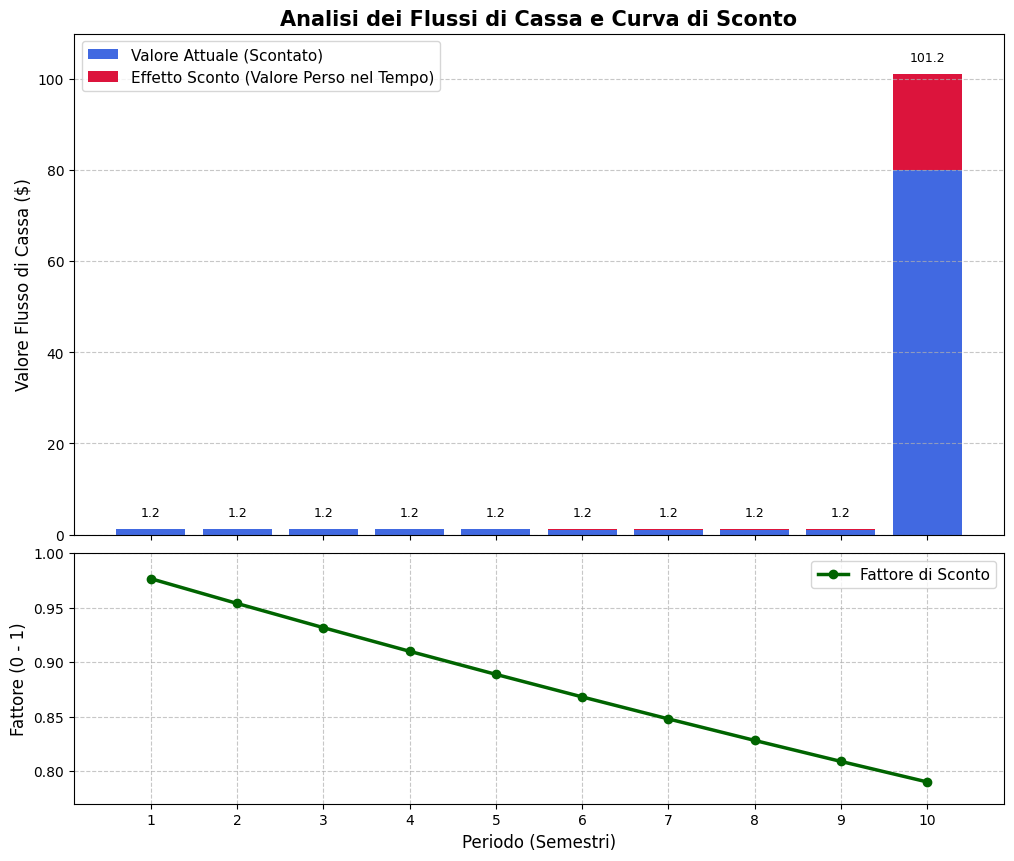

In [69]:
import numpy as np
import matplotlib.pyplot as plt

def bond_cashflows(face_value, coupon_rate, maturity_years, payments_per_year=2):
    periods = int(maturity_years * payments_per_year)
    coupon = face_value * coupon_rate / payments_per_year
    cashflows = np.full(periods, coupon)
    cashflows[-1] += face_value
    return cashflows

def bond_irr(price, cashflows, payments_per_year=2):
    coeffs = np.concatenate(([-price], cashflows))
    roots = np.roots(coeffs)
    real_roots = roots[np.isreal(roots)].real
    valid = real_roots[real_roots > 0]
    if len(valid) == 0:
        raise ValueError("Nessuna radice IRR valida trovata")
    best_root = valid[np.argmin(np.abs(valid - 1))]
    periodic_rate = best_root - 1
    annual_rate = (1 + periodic_rate) ** payments_per_year - 1
    return periodic_rate, annual_rate

# Esempio di bond "vero"
face_value = 100
coupon_rate = 0.025   # 3.5% coupon annuo
maturity_years = 5
price = 90
payments_per_year = 2

# 1. Calcoli base
cashflows = bond_cashflows(face_value, coupon_rate, maturity_years, payments_per_year)
periodic_irr, annual_irr = bond_irr(price, cashflows, payments_per_year)

periods_array = np.arange(1, len(cashflows) + 1)
discount_factor = 1 / ((1 + periodic_irr) ** periods_array)
discounted_cashflows = cashflows * discount_factor
discount_effect = cashflows - discounted_cashflows

# ==========================================
# 3. Creazione Figura con 2 Subplots (Sopra/Sotto)
# ==========================================

# Creiamo una figura con 2 righe (nrows=2) e 1 colonna (ncols=1). 
# sharex=True fa sì che i grafici siano incollati sullo stesso asse orizzontale.
# gridspec_kw imposta il grafico sopra grande il doppio di quello sotto.
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# --- GRAFICO SOPRA (ax1): Istogramma a barre impilate ---
ax1.bar(periods_array, discounted_cashflows, 
        label='Valore Attuale (Scontato)', color='royalblue')
ax1.bar(periods_array, discount_effect, bottom=discounted_cashflows, 
        label='Effetto Sconto (Valore Perso nel Tempo)', color='crimson')

ax1.set_title('Analisi dei Flussi di Cassa e Curva di Sconto', fontsize=15, fontweight='bold')
ax1.set_ylabel('Valore Flusso di Cassa ($)', fontsize=12)
ax1.set_ylim(0, 110)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.legend(fontsize=11, loc='upper left')

# Etichette di testo sopra le barre
for i in range(len(periods_array)):
    ax1.text(periods_array[i], cashflows[i] + 2, f'{cashflows[i]:.1f}', 
             ha='center', va='bottom', fontsize=9)

# --- GRAFICO SOTTO (ax2): Curva del fattore di sconto ---
ax2.plot(periods_array, discount_factor, color='darkgreen', marker='o', 
         linestyle='-', linewidth=2.5, markersize=6, label='Fattore di Sconto')

ax2.set_xlabel('Periodo (Semestri)', fontsize=12)
ax2.set_ylabel('Fattore (0 - 1)', fontsize=12)
# Regoliamo l'asse Y per far vedere meglio la pendenza della curva (es. da 0.7 a 1.05)
ax2.set_ylim(min(discount_factor) - 0.02, 1.00) 
ax2.grid(axis='both', linestyle='--', alpha=0.7)
ax2.legend(fontsize=11, loc='upper right')

# Forziamo le tacche sull'asse X per coincidere con i semestri
plt.xticks(periods_array)

# Avviciniamo un po' i due grafici eliminando lo spazio vuoto in mezzo
plt.subplots_adjust(hspace=0.05)

plt.show()

# Z-Spread, I-Spread, and G-Spread: A Methodological Framework

## Introduction

Whilst yield to maturity (YTM) represents a composite measure of expected return, credit spreads disaggregate the compensation for default risk from the underlying risk-free rate. The three principal metrics—Z-spread, I-spread, and G-spread—operate at different levels of sophistication in decomposing the yield curve and capturing credit risk.

## Z-Spread (Zero-Volatility Spread)

The Z-spread, also known as the static spread in the absence of embedded options, is defined as the constant differential added across all points of the risk-free spot curve that equates the present value of the bond's cash flows to its market price:

$$
P_0 = \sum_{t=1}^{T} \frac{C_t}{(1 + s_t + z)^t}
$$

where $s_t$ denotes the risk-free spot rate at period $t$ and $z$ represents the Z-spread.

**Methodological Characteristics:**
- Eliminates the convexity bias inherent in simple YTM spreads relative to a benchmark rate
- Incorporates the entire term structure of the risk-free curve
- Reflects both credit risk and the relative liquidity profile of the issuer
- Requires specification of the complete spot curve and numerical root-finding techniques

## I-Spread (Interpolated Spread)

The I-spread represents the differential between the YTM of a corporate bond and the interpolated yield on the swap curve or government securities of matching maturity:

$$
\text{I-Spread} = \text{YTM}_{\text{corporate}} - \text{YTM}_{\text{interpolated}}^{\text{risk-free}}
$$

**Applicability and Use Cases:**
- Prevalent market metric for quotation and trading in European fixed income markets
- Practical when the complete spot curve is unavailable or exhibits liquidity constraints
- Sensitive to the choice of reference curve and interpolation methodology
- Occupies a middle ground between theoretical rigor and operational simplicity

## G-Spread (Government Spread)

The G-spread constitutes the simple differential between the YTM of a bond and the YTM of a government security with identical or nearest matching maturity:

$$
\text{G-Spread} = \text{YTM}_{\text{bond}} - \text{YTM}_{\text{government}}^{\text{matching maturity}}
$$

**Limitations and Applications:**
- Intuitively appealing and computationally trivial, yet lacking sophistication in yield curve management
- Insensitive to convexity distortions arising from duration mismatches
- Predominantly employed for rapid comparisons and stakeholder communication
- Provides a useful benchmark for gross spread assessment in standardized reporting

## Comparative Methodology

| Dimension | Z-Spread | I-Spread | G-Spread |
|:---|:---|:---|:---|
| **Reference Curve** | Complete spot curve | Interpolated curve | Single maturity point |
| **Analytical Sophistication** | High | Medium | Low |
| **Convexity Effect** | Fully eliminated | Partially captured | Not accounted for |
| **Market Usage** | OAS, institutional valuation | European trading benchmarks | Quick market checks |
| **Model Dependency** | Moderate | Low | Minimal |

## Relationships Between Metrics

In an efficient market, the three metrics tend to exhibit positive covariance, yet diverge systematically:
- The Z-spread typically remains below the G-spread for long-duration bonds on steep curves, reflecting the term structure premium
- The I-spread provides an intermediate estimate when the curve is properly interpolated
- Significant discrepancies among the metrics signal potential mispricings or deficiencies in the reference curve construction

## Practical Considerations

- **Curve Selection**: The choice between swap, government, and alternative benchmarks materially influences outcomes and requires explicit documentation
- **Risk Composition**: All three spreads incorporate credit risk, liquidity premiums, and implicit volatility components that are difficult to isolate
- **Temporal Dynamics**: Spreads widen systematically during market stress episodes; the Z-spread captures this dynamic more accurately given its incorporation of the complete term structure
- **Regulatory and Accounting Standards**: Different frameworks may mandate specific spread metrics for valuation and disclosure purposes

## Conclusion

The methodological hierarchy Z-spread → I-spread → G-spread reflects a fundamental trade-off between theoretical precision and operational practicality. The selection of the appropriate metric depends upon the valuation context, data availability constraints, and the requisite sophistication level of portfolio analysis. Contemporary fixed income practice increasingly favors Z-spread methodologies for institutional risk management and option-adjusted analysis, whilst market conventions continue to embed I-spread and G-spread quotations in dealer pricing and trade execution.

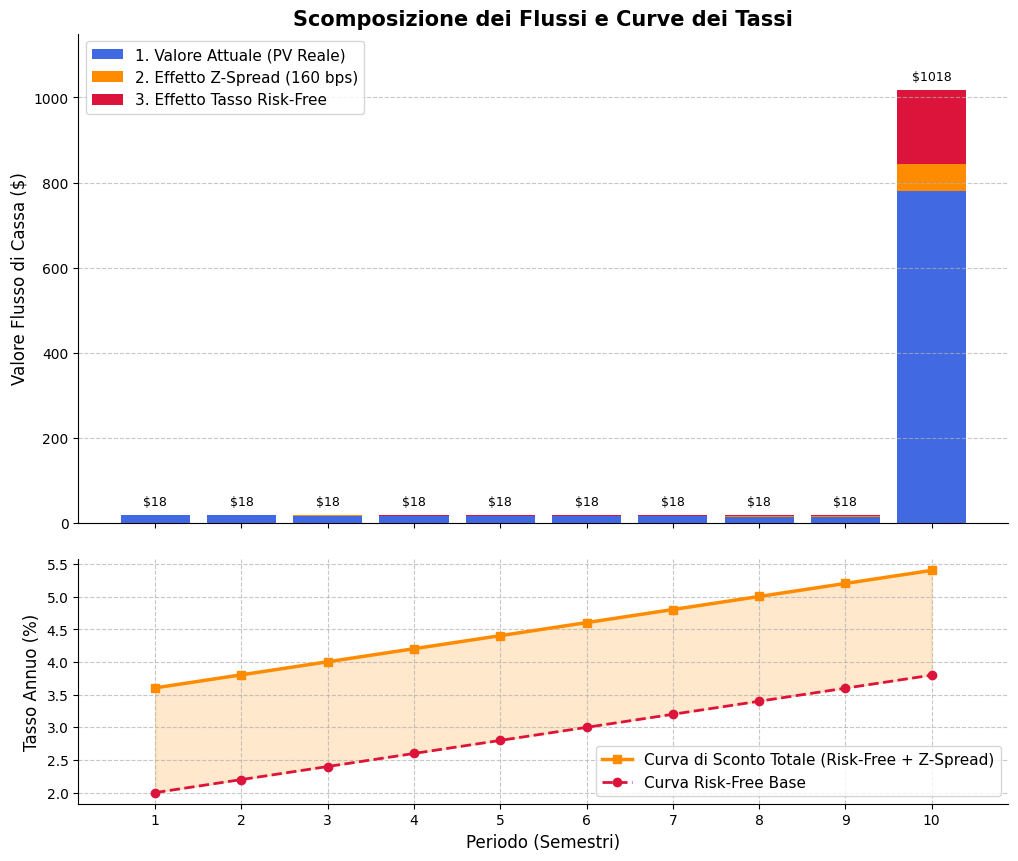

In [70]:
import numpy as np
import matplotlib.pyplot as plt

def bond_cashflows(face_value, coupon_rate, maturity_years, payments_per_year=2):
    periods = int(maturity_years * payments_per_year)
    coupon = face_value * coupon_rate / payments_per_year
    cashflows = np.full(periods, coupon)
    cashflows[-1] += face_value
    return cashflows

# Esempio di bond
face_value = 1000
coupon_rate = 0.035   # 3.5% coupon annuo
maturity_years = 5
price = 920           # Prezzo basso per evidenziare lo spread
payments_per_year = 2

cashflows = bond_cashflows(face_value, coupon_rate, maturity_years, payments_per_year)
periods_array = np.arange(1, len(cashflows) + 1)

# ==========================================
# 1. Definizione della Curva Risk-Free (Spot Curve)
# ==========================================
annual_spot_curve = np.linspace(0.020, 0.038, len(cashflows))
periodic_spot_curve = annual_spot_curve / payments_per_year

# ==========================================
# 2. Calcolo dello Z-Spread (Metodo di Bisezione)
# ==========================================
def calculate_npv_with_zspread(z):
    discount_factors = 1 / ((1 + periodic_spot_curve + z) ** periods_array)
    return np.sum(cashflows * discount_factors)

low, high = -0.5, 0.5 
for _ in range(100):
    mid = (low + high) / 2
    if calculate_npv_with_zspread(mid) > price:
        low = mid
    else:
        high = mid

z_spread_periodic = mid
z_spread_annual = z_spread_periodic * payments_per_year
z_spread_bps = z_spread_annual * 10000

# ==========================================
# 3. Calcolo delle 3 Componenti per il Grafico
# ==========================================
pv_actual = cashflows / ((1 + periodic_spot_curve + z_spread_periodic) ** periods_array)
pv_risk_free = cashflows / ((1 + periodic_spot_curve) ** periods_array)

component_1 = pv_actual                                  
component_2 = pv_risk_free - pv_actual                   
component_3 = cashflows - pv_risk_free                   

# ==========================================
# 4. Creazione Grafico a 2 Pannelli (Sopra/Sotto)
# ==========================================
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# --- GRAFICO SOPRA (ax1): Istogramma a 3 colori ---
ax1.bar(periods_array, component_1, 
        label='1. Valore Attuale (PV Reale)', color='royalblue')
ax1.bar(periods_array, component_2, bottom=component_1, 
        label=f'2. Effetto Z-Spread ({z_spread_bps:.0f} bps)', color='darkorange')
ax1.bar(periods_array, component_3, bottom=component_1 + component_2, 
        label='3. Effetto Tasso Risk-Free', color='crimson')

ax1.set_title('Scomposizione dei Flussi e Curve dei Tassi', fontsize=15, fontweight='bold')
ax1.set_ylabel('Valore Flusso di Cassa ($)', fontsize=12)
ax1.set_ylim(0, 1150)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Etichette in cima alle barre
for i in range(len(periods_array)):
    ax1.text(periods_array[i], cashflows[i] + 15, f'${cashflows[i]:.0f}', 
             ha='center', va='bottom', fontsize=9)

# --- GRAFICO SOTTO (ax2): Curve dei Tassi ---
# Calcoliamo la curva totale (Risk-Free + Z-Spread) in formato annualizzato (%)
annual_total_curve = annual_spot_curve + z_spread_annual

ax2.plot(periods_array, annual_total_curve * 100, color='darkorange', marker='s', 
         linestyle='-', linewidth=2.5, label='Curva di Sconto Totale (Risk-Free + Z-Spread)')
ax2.plot(periods_array, annual_spot_curve * 100, color='crimson', marker='o', 
         linestyle='--', linewidth=2, label='Curva Risk-Free Base')

# Riempiamo l'area tra le due curve per visualizzare lo Z-Spread
ax2.fill_between(periods_array, annual_spot_curve * 100, annual_total_curve * 100, 
                 color='darkorange', alpha=0.2)

ax2.set_xlabel('Periodo (Semestri)', fontsize=12)
ax2.set_ylabel('Tasso Annuo (%)', fontsize=12)
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(axis='both', linestyle='--', alpha=0.7)

# Regolazioni finali per gli assi e la spaziatura
plt.xticks(periods_array)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.subplots_adjust(hspace=0.1)  # Avvicina i due grafici

plt.show()

# Bootstrapping the Term Structure with Linear Interpolation

## Introduction

Bootstrapping is the canonical technique for deriving the zero-coupon yield curve from a set of market-observed fixed-income instruments. In fixed income theory, the term structure of interest rates is represented by the sequence of spot rates associated with successive maturities. Because most liquid instruments pay coupons, the term structure cannot be observed directly; bootstrapping reconstructs it iteratively by solving for spot rates that reproduce instrument prices under absence of arbitrage.

## Methodological Foundations

Consider a set of coupon-paying securities with ascending maturities. Let $P_0^{(i)}$ denote the market price of the $i$-th security, $C_t^{(i)}$ its cash flow at time $t$, and $s_t$ the spot rate for maturity $t$. The no-arbitrage condition requires that

$$
P_0^{(i)} = \sum_{t=1}^{T_i} \frac{C_t^{(i)}}{(1 + s_t)^t}
$$

for each instrument $i$. Because the earliest maturities are replicated by instruments with only one or few cash flows, the corresponding spot rates can be solved directly. Subsequent maturities are then solved sequentially by discounting earlier cash flows with previously determined spot rates and isolating the unknown spot rate for the longest cash flow.

This iterative procedure yields a discrete set of zero-coupon rates $\{s_1, s_2, \ldots, s_T\}$ that are internally consistent with observed bond prices.

## Bootstrapping Procedure

1. Select a set of benchmark instruments with clean prices and standardized conventions.
2. Order instruments by increasing maturity.
3. For the shortest-maturity instrument, solve directly for the first spot rate.
4. For the next instrument, discount all earlier coupon payments using previously obtained spot rates and solve for the next unknown spot rate.
5. Repeat until all maturities of interest are covered.

In mathematical terms, for the $n$-th instrument with cash flows $C_1, \ldots, C_{T_n}$, the spot rate $s_{T_n}$ is obtained from:

$$
s_{T_n} = \left( \frac{C_{T_n}}{P_0^{(n)} - \sum_{t=1}^{T_n - 1} \frac{C_t}{(1 + s_t)^t}} \right)^{1/T_n} - 1
$$

provided the earlier spot rates $s_1, \ldots, s_{T_n-1}$ are already known.

## The Role of Interpolation

Market instruments do not exist for every possible maturity. Consequently, bootstrapped spot rates are often available only at discrete points corresponding to liquid benchmark maturities. To obtain a continuous or finer-grained term structure, interpolation is required.

Linear interpolation is the simplest and most transparent method. Given two known spot rates $s_a$ and $s_b$ at maturities $t_a$ and $t_b$ respectively, the interpolated spot rate $s_t$ for any intermediate maturity $t$ with $t_a < t < t_b$ is given by:

$$
s_t = s_a + \frac{(s_b - s_a)}{(t_b - t_a)} \cdot (t - t_a)
$$

This procedure assumes that the yield curve between the two anchor points is locally linear in maturity. In academic terms, linear interpolation imposes a piecewise affine structure on the discrete spot rate sequence.

## Specifics of Linear Interpolation in Term Structure Construction

When applying linear interpolation to bootstrapped rates, it is important to distinguish between interpolation of spot rates and interpolation of discount factors. In a textbook framework, the preferred approach is often to interpolate discount factors or zero rates, because these objects preserve the monotonicity and convexity properties implied by absence of arbitrage more directly than raw forward rates.

For spot rates:

- Compute the interpolated zero rate for maturity $t$ as a weighted average of neighboring bootstrapped zero rates.
- Use the result to derive the associated discount factor $D(t) = (1 + s_t)^{-t}$.

For discount factors:

- Interpolate $D(t)$ linearly between known maturities.
- Derive the implied spot rate as $s_t = D(t)^{-1/t} - 1$.

Linear interpolation is advantageous because it is easy to implement and yields continuous rates. However, it may produce unrealistic curvature and can understate the true term premium when the underlying curve exhibits pronounced convexity.

## Practical Considerations

- Data quality: Bootstrapping is sensitive to market quotes, settlement conventions, and day-count conventions. Consistent input data are essential.
- Instrument selection: Choose benchmarks that are liquid and representative of the desired segment of the curve.
- Interpolation choice: Linear interpolation is appropriate for a first approximation, but more sophisticated techniques (e.g., cubic splines, Nelson-Siegel, Svensson) may be required for smoother and more economically plausible curves.
- Consistency: The interpolated curve must preserve absence of arbitrage across maturities and produce discount factors that decline monotonically with time.

## Conclusion

Bootstrapping provides a rigorous mechanism for constructing the zero-coupon term structure from coupon-bearing securities. Linear interpolation offers a straightforward means of filling the gaps between discrete bootstrapped maturities, enabling the generation of a practically usable curve. In academic fixed income analysis, the combination of iterative bootstrapping and careful interpolation constitutes the foundation for term structure modeling and valuation.

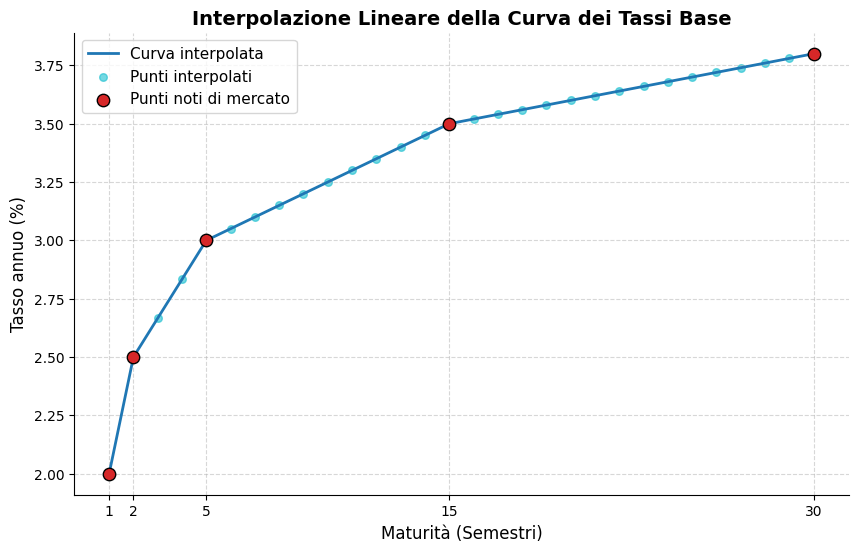

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dati Iniziali
maturities_known = np.array([1, 2, 5, 15, 30])
spot_rates_known = np.array([0.02, 0.025, 0.03, 0.035, 0.038])

# 2. Creazione asse X (tutte le maturità da 1 a 30)
maturities_interp = np.arange(1, 31)

# 3. Interpolazione Lineare Vettorizzata con NumPy
spot_rates_interp = np.interp(maturities_interp, maturities_known, spot_rates_known)

# 4. Creazione Grafico
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(maturities_interp, spot_rates_interp * 100, color='tab:blue', linewidth=2, label='Curva interpolata')
ax.scatter(maturities_interp, spot_rates_interp * 100, color='tab:cyan', s=30, alpha=0.6, label='Punti interpolati')
ax.scatter(maturities_known, spot_rates_known * 100, color='tab:red', s=80, edgecolor='black', zorder=5, label='Punti noti di mercato')

ax.set_title('Interpolazione Lineare della Curva dei Tassi Base', fontsize=14, fontweight='bold')
ax.set_xlabel('Maturità (Semestri)', fontsize=12)
ax.set_ylabel('Tasso annuo (%)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11)

# Imposta le tacche dell'asse X esattamente sui punti noti
plt.xticks(maturities_known)

# Rimuove i bordi in alto e a destra per un look più pulito
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

# Forward Rates in Fixed Income Term Structure Analysis

## Introduction

Forward rates are the implied future short-term interest rates derived from the current term structure of spot rates. They represent the market's expectation, under no-arbitrage conditions, of the rate that will prevail over a future interval, conditional on the current yield curve. In academic fixed income analysis, forward rates are a fundamental construct for decomposing the term structure, valuing forward-starting contracts, and understanding the intertemporal allocation of risk-free returns.

## Definition

Given a sequence of zero-coupon spot rates $s_t$ for maturities $t = 1, 2, \ldots, T$, the forward rate $f_{t-1,t}$ between time $t-1$ and $t$ is defined by:

$$
(1 + s_t)^t = (1 + s_{t-1})^{t-1} \cdot (1 + f_{t-1,t})
$$

Solving for the one-period forward rate gives:

$$
1 + f_{t-1,t} = \frac{(1 + s_t)^t}{(1 + s_{t-1})^{t-1}}
$$

For general horizons, the $(T_1, T_2)$ forward rate is:

$$
1 + f_{T_1,T_2} = \frac{(1 + s_{T_2})^{T_2}}{(1 + s_{T_1})^{T_1}}
$$

where $T_2 > T_1$.

## Theoretical Interpretation

Forward rates are not necessarily forecasts of future spot rates; rather, they are implied yields consistent with the current term structure under the assumption of no arbitrage. In a frictionless market, the forward rate equals the rate at which investors can lock in borrowing or lending for a future period today. Thus, forward rates can be interpreted as equilibrium prices for future risk-free claims.

From the perspective of discount factors $D(t) = (1 + s_t)^{-t}$, the forward rate between $T_1$ and $T_2$ satisfies:

$$
D(T_2) = D(T_1) \cdot \frac{1}{1 + f_{T_1,T_2}}
$$

This expression highlights that forward rates are intrinsic to the multiplicative structure of discount factors.

## Relationship with Spot Rates and Yield Curve Dynamics

Forward rates provide a decomposition of the spot curve. If the spot curve is upward sloping, the implied forward rates are typically higher than current short-term rates, reflecting the market’s pricing of future opportunity cost or term premium. Conversely, a downward-sloping spot curve implies lower implied forward rates, often associated with expected monetary easing or recessionary expectations.

The sequence of forward rates can be obtained from the spot curve and used to reconstruct the original spot rates:

$$
(1 + s_T)^T = \prod_{t=1}^{T} (1 + f_{t-1,t})
$$

This identity emphasizes that the spot rate for maturity $T$ is a compounded average of the sequence of one-period forward rates from time 0 to $T$.

## DV01 and Price Value of a Basis Point

DV01 (Dollar Value of One Basis Point), also termed Price Value of a Basis Point (PVBP), quantifies the dollar amount of price change resulting from a one-basis-point (0.01%) shift in yield. It is computed as:

$$
\text{DV01} = D_{\text{Mod}} \times P_0 \times 0.0001
$$

where $D_{\text{Mod}}$ is the modified duration and $P_0$ is the bond's current market price.

DV01 provides an intuitive metric for traders and risk managers by expressing interest rate sensitivity in absolute dollar terms rather than as a percentage or duration measure. A bond with DV01 of $50 will appreciate by $50 if yields decline by one basis point, and depreciate by $50 if yields rise by one basis point (up to the approximation limits imposed by convexity).

The DV01 metric is particularly useful in:
- **Hedge ratio construction**: determining the notional size of derivative instruments required to neutralize interest rate exposure.
- **Risk reporting**: communicating the magnitude of potential losses or gains from small, routine market movements.
- **Position sizing**: constraining portfolio risk by setting maximum acceptable DV01 thresholds per position or portfolio.

For the bond analyzed in the prior section, with modified duration of 9.02 periods and price of $944.02, the DV01 is approximately $0.84 per basis point movement, reflecting moderate price sensitivity to yield changes.
## Practical Importance

Forward rates are central in several fixed income applications:

- Pricing forward-rate agreements and interest rate swaps.
- Constructing forward curves for risk management and asset-liability modeling.
- Separating pure expectations from term premium components when decomposing yields.
- Assessing arbitrage relationships between bonds of differing maturities.

In empirical fixed income research, distinguishing between the expectations interpretation and the no-arbitrage interpretation of forward rates is essential. The former relates to predicted future spot rates, while the latter is concerned with internal consistency of discount factors.

## Conclusion

Forward rates provide a rigorous link between current yield curve observations and the implied structure of future short-term rates. In a textbook treatment, they are presented as derived quantities consistent with the underlying zero-coupon curve, serving both theoretical and practical roles in fixed income valuation and term structure analysis.

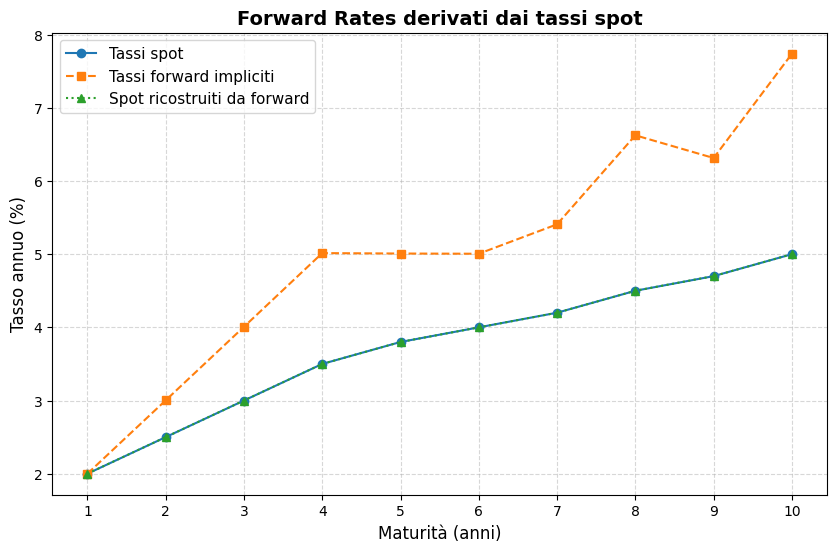

In [67]:
def forward_rates_from_spot(spot_rates):
    tenors = np.arange(1, len(spot_rates) + 1)
    forward_rates = np.empty_like(spot_rates)
    forward_rates[0] = spot_rates[0]
    for i in range(1, len(spot_rates)):
        forward_rates[i] = (1 + spot_rates[i]) ** (i + 1) / (1 + spot_rates[i - 1]) ** i - 1
    return forward_rates

def implied_spot_from_forwards(forward_rates):
    spot_rates = np.empty_like(forward_rates)
    for i in range(len(forward_rates)):
        spot_rates[i] = np.prod(1 + forward_rates[: i + 1]) ** (1 / (i + 1)) - 1
    return spot_rates

annual_spot_curve = np.array([0.02, 0.025, 0.03, 0.035, 0.038, 0.04, 0.042, 0.045, 0.047, 0.05])
tenors = np.arange(1, len(annual_spot_curve) + 1)
forward_rates = forward_rates_from_spot(annual_spot_curve)
reconstructed_spot = implied_spot_from_forwards(forward_rates)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(tenors, annual_spot_curve * 100, marker='o', label='Tassi spot')
ax.plot(tenors, forward_rates * 100, marker='s', linestyle='--', label='Tassi forward impliciti')
ax.plot(tenors, reconstructed_spot * 100, marker='^', linestyle=':', label='Spot ricostruiti da forward')

ax.set_title('Forward Rates derivati dai tassi spot', fontsize=14, fontweight='bold')
ax.set_xlabel('Maturità (anni)', fontsize=12)
ax.set_ylabel('Tasso annuo (%)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11)
plt.xticks(tenors)
plt.show()

# Duration and Convexity: Foundational Measures of Fixed Income Price Sensitivity

## Introduction

Duration and convexity are the cornerstone metrics in fixed income analysis for quantifying the sensitivity of bond prices to changes in yield. While yield to maturity (YTM) provides a single composite measure of return, duration and convexity decompose the price-yield relationship into its linear and nonlinear components. This framework enables investors and risk managers to assess the magnitude and direction of price movements arising from term structure shifts and to construct immunization strategies that protect portfolios against interest rate risk.

## Macaulay Duration

### Definition and Intuition

Macaulay duration, named after Frederick Macaulay's foundational 1938 work, is defined as the weighted average time to receipt of a bond's cash flows, where weights are proportional to the present value of each cash flow:

$$
D_{\text{Mac}} = \frac{\sum_{t=1}^{T} t \cdot \frac{C_t}{(1 + y)^t}}{P_0} = \frac{1}{P_0} \sum_{t=1}^{T} t \cdot \frac{C_t}{(1 + y)^t}
$$

where $C_t$ denotes the cash flow at time $t$, $y$ is the yield to maturity (expressed as a periodic rate), $P_0$ is the bond's current market price, and $T$ is the number of periods to maturity.

Intuitively, Macaulay duration captures the temporal center of gravity of the bond's cash flow stream. A bond with all cash flows concentrated at maturity (such as a zero-coupon bond) exhibits duration equal to its time to maturity. Conversely, a bond with large intermediate coupon payments possesses a Macaulay duration shorter than its term to maturity, reflecting the earlier weighted receipt of cash.

### Characteristics and Interpretation

- **Units of measurement**: Macaulay duration is expressed in years (or periods, depending on the payment frequency).
- **Lower bound**: For a coupon-bearing bond, Macaulay duration is always less than time to maturity.
- **Upper bound**: Macaulay duration cannot exceed the maturity date.
- **Coupon effect**: Higher coupon rates produce shorter durations, since investors receive larger proportional cash flows in the near term.
- **Yield effect**: An increase in prevailing yields reduces Macaulay duration slightly, because present values of distant cash flows diminish relative to near-term flows.

The Macaulay duration of a bond can be computed directly from its yield and coupon structure, making it readily applicable in comparative analysis across instruments with different maturities and coupon rates.

## Modified Duration

### Definition and Relationship to Macaulay Duration

Modified duration translates Macaulay duration into a direct elasticity measure of price with respect to yield changes. It is defined as:

$$
D_{\text{Mod}} = \frac{D_{\text{Mac}}}{1 + y}
$$

where $y$ is the periodic yield to maturity.

Modified duration quantifies the approximate percentage change in bond price resulting from a one-basis-point (0.01%) change in yield. More precisely:

$$
\frac{\Delta P}{P_0} \approx -D_{\text{Mod}} \cdot \Delta y
$$

The negative sign reflects the inverse relationship between bond prices and yields: as yields rise, bond prices fall, and vice versa.

### Interpretation and Practical Use

Modified duration serves as the primary sensitivity metric in fixed income portfolio management. Key properties include:

- **Direct price elasticity**: A bond with modified duration of 5 years will experience approximately a 5% price decline if yields rise by 100 basis points.
- **Portfolio aggregation**: The modified duration of a portfolio is the weighted average of individual bond durations, facilitating rapid risk assessment across complex holdings.
- **DV01 (Dollar Value of One Basis Point)**: The dollar impact of a one-basis-point yield change is computed as $\text{DV01} = D_{\text{Mod}} \times P_0 \times 0.0001$, providing an intuitive measure for traders and risk managers.
- **Immunization**: Modified duration underpins classical immunization strategies, wherein the duration of assets is matched to the duration of liabilities, rendering the portfolio insensitive to parallel yield curve shifts.

### Limitations

Modified duration is valid only for small yield changes. As yield movements become larger, the linear approximation degrades, and higher-order terms become material. This is where convexity becomes essential.

## Convexity

### Definition and Mathematical Formulation

Convexity measures the curvature of the price-yield relationship and captures the second-order (nonlinear) sensitivity of bond price to yield changes. It is defined as:

$$
\text{Convexity} = \frac{1}{P_0} \cdot \frac{d^2 P}{d y^2}
$$

For a bond with cash flows $C_t$, convexity is computed as:

$$
\text{Convexity} = \frac{1}{P_0 (1 + y)^2} \sum_{t=1}^{T} t(t+1) \cdot \frac{C_t}{(1 + y)^t}
$$

Convexity is typically expressed in units of (years)$^2$ or normalized as a number without explicit time units.

### Interpretation and Significance

Convexity captures the manner in which the bond's duration itself changes as yields move. It reflects the fact that the price-yield curve is convex (curving upward) rather than linear:

- **For positive yields**: All bonds exhibit positive convexity, meaning the price increase from a yield decrease exceeds the price decrease from an equal-magnitude yield increase.
- **Benefit to bondholders**: Positive convexity provides an asymmetric gain: investors benefit more from favorable yield movements than they lose from unfavorable ones of equal magnitude.
- **Embedded options**: Bonds with embedded call options exhibit negative convexity over certain yield ranges, because the issuer's exercise decision caps upside price appreciation.

### Relationship to Duration

The second-order Taylor expansion of the price-yield relationship is:

$$
\Delta P \approx -D_{\text{Mod}} \cdot P_0 \cdot \Delta y + \frac{1}{2} \cdot \text{Convexity} \cdot P_0 \cdot (\Delta y)^2
$$

This expression decomposes the total price change into a duration effect (linear term) and a convexity effect (nonlinear term). For large yield movements, the convexity adjustment becomes material and must be incorporated for accurate valuation.

## Comparative Analysis: Duration and Convexity Across Bond Types

| Bond Type | Macaulay Duration | Modified Duration | Convexity | Remarks |
|:---|:---|:---|:---|:---|
| **Zero-coupon** | Equals maturity | Lowest for given maturity | Highest | All cash at maturity; duration is deterministic |
| **Par bond** (coupon = yield) | Less than maturity | Moderate | Moderate | Balanced cash flow timing; standard benchmark |
| **Premium bond** (price > face) | Shorter than par | Lower | Higher | Coupons exceed yield; front-loaded cash flows |
| **Discount bond** (price < face) | Longer than par | Higher | Lower | Coupons below yield; back-loaded cash flows |
| **Callable bond** | Variable; may contract | Reduced over certain ranges | Negative (at high yields) | Embedded option reduces effective duration |

## Practical Considerations

### Duration in Portfolio Management

Duration is the primary tool for:
- Estimating the expected price impact of parallel yield curve shifts.
- Constructing hedge ratios for interest rate derivatives (futures, swaps, swaptions).
- Aligning asset and liability durations in asset-liability management.
- Comparing relative value across bonds of different maturities and coupons.

### Convexity Adjustments

Convexity becomes increasingly important:
- When yield volatility is high, amplifying the frequency and magnitude of yield movements.
- For long-duration instruments (e.g., 30-year bonds), where curvature effects are pronounced.
- In valuation of embedded options, where the asymmetric price response is economically significant.
- In hedging strategies that require second-order precision.

### Market Quotations and Conventions

- Duration and convexity computations depend critically on day-count conventions (Actual/Actual, 30/360), compounding frequency (annual, semiannual), and settlement date assumptions.
- Market data providers typically quote modified duration and money duration (the product of duration and price) for rapid portfolio assessment.
- Institutions conducting rigorous risk management compute both Macaulay and modified duration to ensure consistency across analytical frameworks.

## Conclusion

Macaulay duration provides a theoretically grounded measure of the weighted average timing of cash flows, whilst modified duration translates this concept into a direct price elasticity suitable for portfolio risk management. Convexity captures the nonlinear curvature of the price-yield relationship, providing material refinements to duration-based approximations when yield movements are large or when embedded options are present. Together, duration and convexity form the bedrock of fixed income analytics, enabling systematic quantification of interest rate risk and the design of effective hedging and immunization strategies.

In [71]:
def macaulay_duration(cashflows, periodic_rate):
    """
    Calculates Macaulay Duration
    
    Parameters:
    - cashflows: array of cash flows
    - periodic_rate: periodic yield to maturity (e.g., semiannual rate)
    
    Returns:
    - macaulay_duration: weighted average time to cash flow receipt (in periods)
    """
    periods = np.arange(1, len(cashflows) + 1)
    pv_cashflows = cashflows / ((1 + periodic_rate) ** periods)
    bond_price = np.sum(pv_cashflows)
    
    weighted_periods = np.sum(periods * pv_cashflows)
    mac_duration = weighted_periods / bond_price
    
    return mac_duration, bond_price

def modified_duration(macaulay_dur, periodic_rate):
    """
    Calculates Modified Duration from Macaulay Duration
    
    Parameters:
    - macaulay_dur: Macaulay duration
    - periodic_rate: periodic yield to maturity
    
    Returns:
    - modified_duration: price sensitivity to yield changes (in periods)
    """
    mod_duration = macaulay_dur / (1 + periodic_rate)
    return mod_duration

def convexity(cashflows, periodic_rate):
    """
    Calculates Convexity
    
    Parameters:
    - cashflows: array of cash flows
    - periodic_rate: periodic yield to maturity
    
    Returns:
    - convexity: second-order price sensitivity
    """
    periods = np.arange(1, len(cashflows) + 1)
    pv_cashflows = cashflows / ((1 + periodic_rate) ** periods)
    bond_price = np.sum(pv_cashflows)
    
    convexity_numerator = np.sum(periods * (periods + 1) * pv_cashflows)
    conv = convexity_numerator / (bond_price * ((1 + periodic_rate) ** 2))
    
    return conv

# Calculate duration and convexity for the bond
mac_dur, bond_price = macaulay_duration(cashflows, periodic_irr)
mod_dur = modified_duration(mac_dur, periodic_irr)
conv = convexity(cashflows, periodic_irr)

print(f"Bond Price: ${bond_price:.2f}")
print(f"Macaulay Duration: {mac_dur:.4f} periods ({mac_dur/2:.4f} years)")
print(f"Modified Duration: {mod_dur:.4f} periods ({mod_dur/2:.4f} years)")
print(f"Convexity: {conv:.4f}")
print(f"\nDV01 ($ value of 1 bp): ${(mod_dur * bond_price * 0.0001):.4f}")

Bond Price: $944.02
Macaulay Duration: 9.2339 periods (4.6169 years)
Modified Duration: 9.0187 periods (4.5093 years)
Convexity: 94.2970

DV01 ($ value of 1 bp): $0.8514


# Sensitivity Analysis to Level, Steepness, and Curvature

## Introduction

In fixed income term structure analysis, the shape of the yield curve is commonly decomposed into three orthogonal movements: level, steepness, and curvature. This factor representation provides a parsimonious framework for assessing how bond valuations and risk measures respond to shifts in the term structure.

## Level

The level factor corresponds to a parallel shift of the entire yield curve. It is the simplest dimension of curve movement and reflects a uniform change in interest rates across all maturities.

- Theoretical interpretation: a change in the level factor is equivalent to a common shock to the risk-free discount rate for all tenors.
- Sensitivity measure: the portfolio’s exposure to level is closely related to duration and DV01, since a parallel shift impacts all cash flows proportionally.
- Practical implication: level risk dominates when the yield curve moves up or down without changing its shape, as in broad monetary policy shifts.

## Steepness

Steepness refers to the slope of the yield curve, typically measured by the spread between long-term and short-term rates.

- Theoretical interpretation: a steepness movement captures relative changes between short and long maturities, reflecting expectations about the growth and inflation horizon.
- Sensitivity measure: slope exposure can be quantified by the difference in duration-weighted exposures between long and short segments, or by regression on a long-short basis.
- Practical implication: steepness risk is central to strategies that exploit yield curve flattening or steepening, such as carry trades, curve roll-down, and political cycle positioning.

## Curvature

Curvature describes the degree of bending in the term structure, often associated with a hump in the middle part of the curve.

- Theoretical interpretation: curvature changes isolate the middle maturities from the ends of the curve, representing non-linear distortions in the term structure.
- Sensitivity measure: curvature exposure is usually extracted as the residual orthogonal component after level and steepness, and is important for portfolios concentrated in intermediate maturities.
- Practical implication: curvature risk is relevant for butterfly trades and for instruments sensitive to medium-term rate expectations, such as callable bonds and certain swap structures.

## Factor Decomposition

A common textbook approach employs principal component analysis or parametric yield curve models to separate these effects:

- level = first principal component, capturing the bulk of variance;
- steepness = second principal component, capturing the tilt between short and long ends;
- curvature = third principal component, capturing the hump-shaped adjustment.

In a parametric setting, models such as Nelson–Siegel or Svensson express the forward curve as a combination of level, slope, and curvature basis functions, allowing direct interpretation of sensitivities.

## Risk Management Perspective

Analyzing sensitivity to level, steepness, and curvature supports several key functions:

- portfolio immunization: matching factor exposures to liabilities reduces vulnerability to specific curve movements;
- risk attribution: decomposing P&L into factor contributions clarifies whether losses arise from broad rate shifts, relative curve changes, or shape distortions;
- hedging: targeted hedges can be constructed using instruments with complementary exposure to the three factors.

## Conclusion

The triad of level, steepness, and curvature provides a coherent theoretical taxonomy for yield curve sensitivity. In academic fixed income literature, these factors serve as the core dimensions of term structure risk, enabling both rigorous valuation and disciplined risk control.